# Ghost in the Machine: Results Analysis

Publication-quality visualizations for the prompt injection detection research.
All figures are saved to `results/figures/` at 300 DPI.


In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from matplotlib.patches import FancyBboxPatch

warnings.filterwarnings('ignore')

# --- Style ---
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# Colorblind-friendly palette (Okabe-Ito)
C = {
    'blue': '#0072B2', 'orange': '#E69F00', 'green': '#009E73',
    'red': '#D55E00', 'purple': '#CC79A7', 'cyan': '#56B4E9',
    'yellow': '#F0E442', 'black': '#000000', 'grey': '#999999',
}

# --- Paths ---
ROOT = Path('..') if Path('../data').exists() else Path('.')
DATA = ROOT / 'data' / 'processed'
RESULTS = ROOT / 'results'
FIG_DIR = RESULTS / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

def savefig(fig, name):
    fig.savefig(FIG_DIR / f'{name}.png', bbox_inches='tight', dpi=300)
    print(f'Saved: {FIG_DIR / name}.png')


## 1. Dataset Analysis


In [2]:
# Load all splits
train_df = pd.read_csv(DATA / 'train.csv')
val_df = pd.read_csv(DATA / 'val.csv')
test_df = pd.read_csv(DATA / 'test.csv')
zeroday_df = pd.read_csv(DATA / 'test_zeroday.csv')
combined = pd.read_csv(DATA / 'combined_dataset.csv')

with open(DATA / 'data_summary.json') as f:
    summary = json.load(f)

# Load evaluation results
with open(RESULTS / 'evaluation_results.json') as f:
    eval_results = json.load(f)

with open(RESULTS / 'training_history.json') as f:
    history = json.load(f)

print(f'Total unique samples: {len(combined)}')
print(f'Splits: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}, zeroday={len(zeroday_df)}')


Total unique samples: 1137
Splits: train=767, val=165, test=165, zeroday=40


### 1a. Class Distribution (Malicious vs Benign)


Saved: ..\results\figures\class_distribution.png


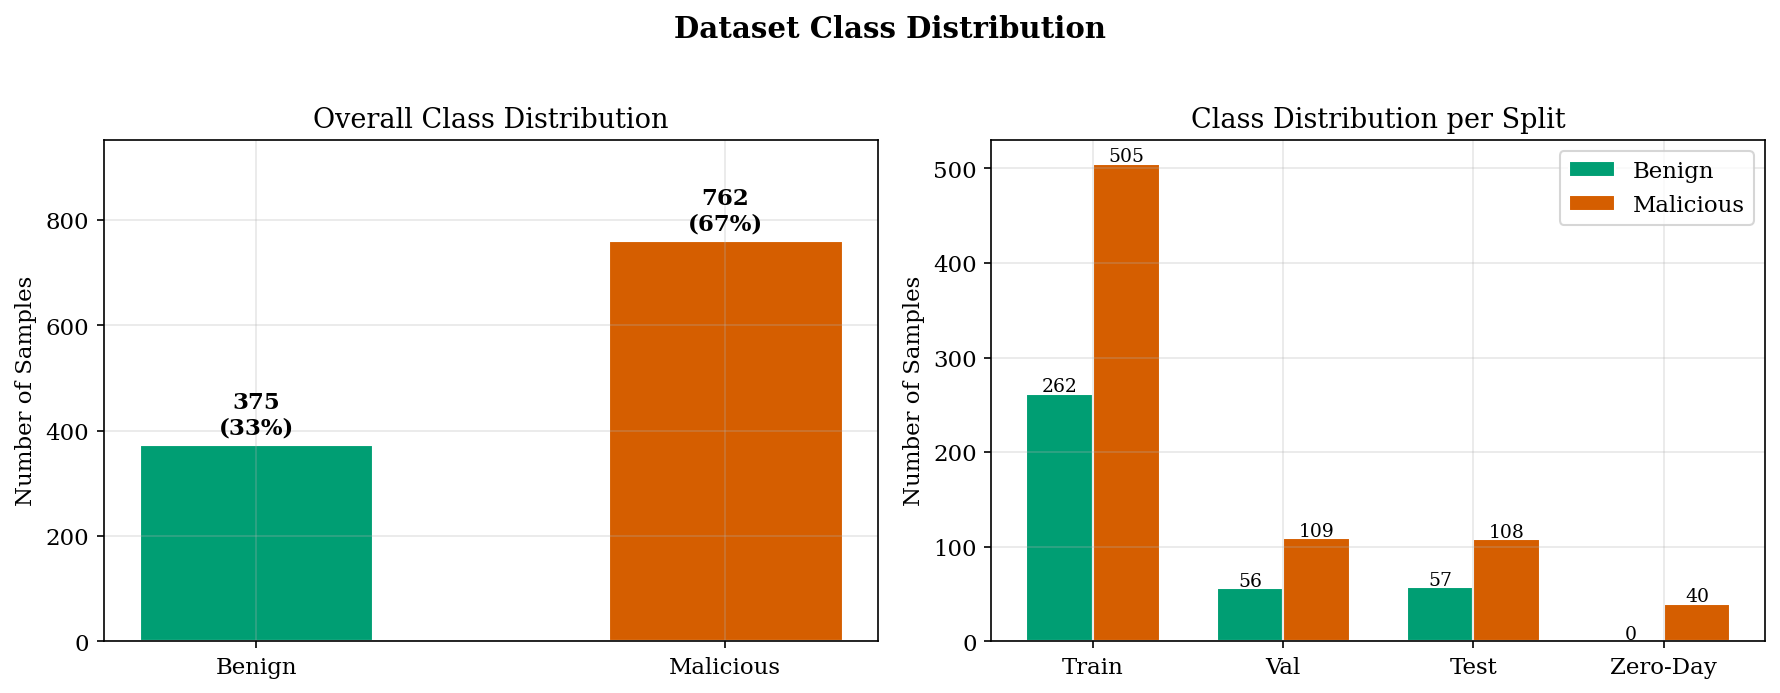

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Overall distribution
labels_map = {1: 'Malicious', 0: 'Benign'}
counts = combined['label'].value_counts().sort_index()
colors = [C['green'], C['red']]
bars = axes[0].bar([labels_map[i] for i in counts.index], counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f'{v}\n({v/len(combined):.0%})', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Overall Class Distribution')
axes[0].set_ylabel('Number of Samples')
axes[0].set_ylim(0, max(counts.values) * 1.25)

# Per-split distribution
splits = {'Train': train_df, 'Val': val_df, 'Test': test_df, 'Zero-Day': zeroday_df}
x = np.arange(len(splits))
mal = [int((df['label'] == 1).sum()) for df in splits.values()]
ben = [int((df['label'] == 0).sum()) for df in splits.values()]
w = 0.35
axes[1].bar(x - w/2, ben, w, label='Benign', color=C['green'], edgecolor='white')
axes[1].bar(x + w/2, mal, w, label='Malicious', color=C['red'], edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(splits.keys())
axes[1].set_title('Class Distribution per Split')
axes[1].set_ylabel('Number of Samples')
axes[1].legend()
for i, (b, m) in enumerate(zip(ben, mal)):
    axes[1].text(i - w/2, b + 2, str(b), ha='center', fontsize=9)
    axes[1].text(i + w/2, m + 2, str(m), ha='center', fontsize=9)

fig.suptitle('Dataset Class Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
savefig(fig, 'class_distribution')
plt.show()


### 1b. Attack Category Breakdown


Saved: ..\results\figures\attack_category_distribution.png


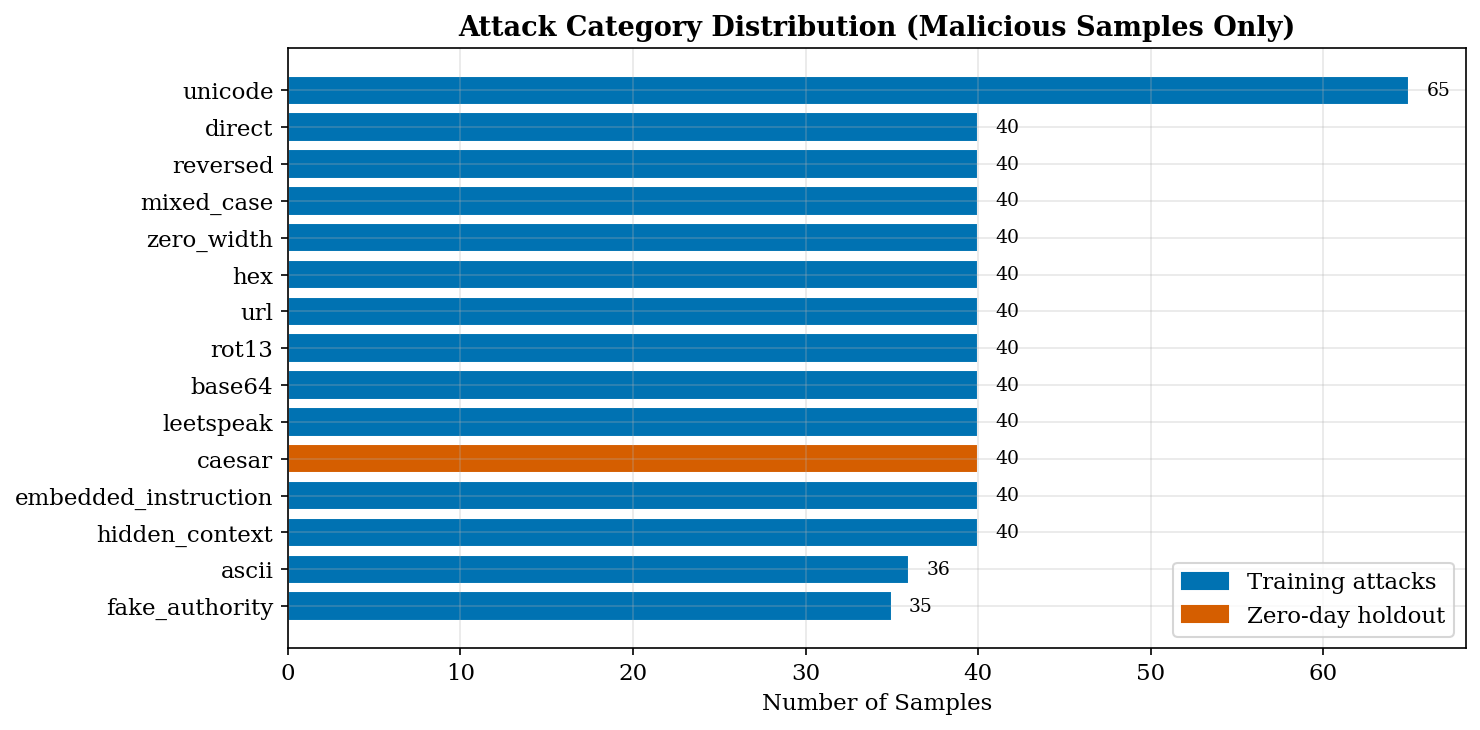

In [4]:
attack_counts = combined[combined['label'] == 1]['attack_category'].value_counts()
attack_counts = attack_counts[attack_counts.index != 'none'].head(15)

fig, ax = plt.subplots(figsize=(10, 5))
colors_list = [C['red'] if cat in ('homoglyph', 'caesar') else C['blue'] for cat in attack_counts.index]
bars = ax.barh(range(len(attack_counts)), attack_counts.values, color=colors_list, edgecolor='white')
ax.set_yticks(range(len(attack_counts)))
ax.set_yticklabels(attack_counts.index)
ax.invert_yaxis()
ax.set_xlabel('Number of Samples')
ax.set_title('Attack Category Distribution (Malicious Samples Only)', fontweight='bold')
for i, v in enumerate(attack_counts.values):
    ax.text(v + 1, i, str(v), va='center', fontsize=9)

# Legend for zero-day
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=C['blue'], label='Training attacks'), Patch(color=C['red'], label='Zero-day holdout')], loc='lower right')

plt.tight_layout()
savefig(fig, 'attack_category_distribution')
plt.show()


### 1c. Source Dataset Contribution


Saved: ..\results\figures\source_distribution.png


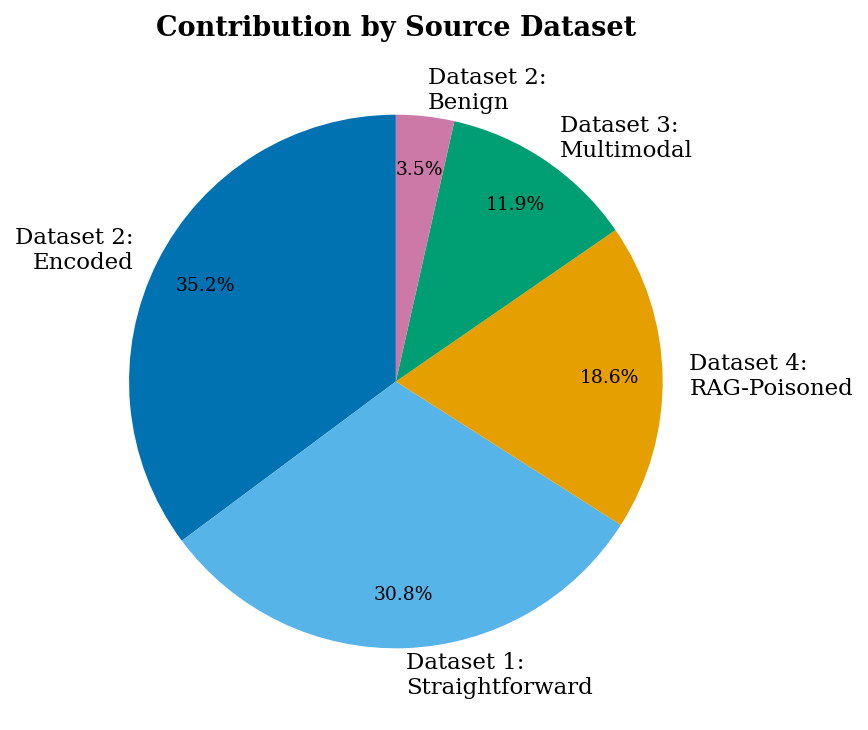

In [5]:
source_counts = combined['source'].value_counts()
source_labels = {'encoded_attacks': 'Dataset 2:\nEncoded', 'straightforward': 'Dataset 1:\nStraightforward', 'rag_poisoned': 'Dataset 4:\nRAG-Poisoned', 'multimodal': 'Dataset 3:\nMultimodal', 'encoded_benign': 'Dataset 2:\nBenign'}

fig, ax = plt.subplots(figsize=(8, 5))
palette = [C['blue'], C['cyan'], C['orange'], C['green'], C['purple']]
labels = [source_labels.get(s, s) for s in source_counts.index]
wedges, texts, autotexts = ax.pie(source_counts.values, labels=labels, autopct='%1.1f%%', colors=palette[:len(source_counts)], startangle=90, pctdistance=0.8)
for t in autotexts:
    t.set_fontsize(9)
ax.set_title('Contribution by Source Dataset', fontweight='bold')
plt.tight_layout()
savefig(fig, 'source_distribution')
plt.show()


### 1d. Text Length Distribution


Saved: ..\results\figures\text_length_distribution.png


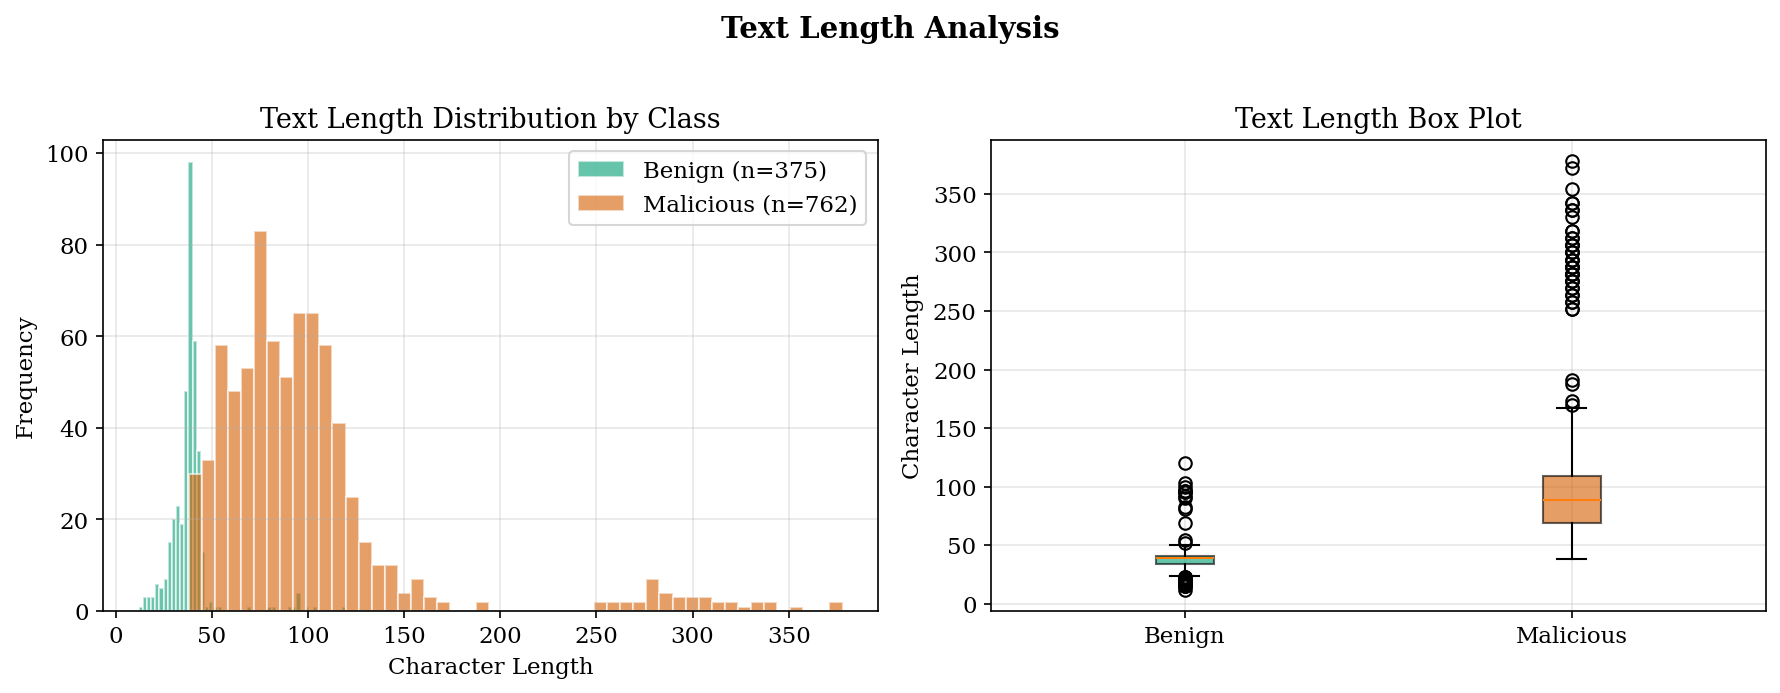

Benign  - mean: 39, median: 39
Malicious - mean: 98, median: 88


In [6]:
combined['text_len'] = combined['text'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for label, color, name in [(0, C['green'], 'Benign'), (1, C['red'], 'Malicious')]:
    subset = combined[combined['label'] == label]['text_len']
    axes[0].hist(subset, bins=50, alpha=0.6, color=color, label=f'{name} (n={len(subset)})', edgecolor='white')
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Text Length Distribution by Class')
axes[0].legend()

data_by_class = [combined[combined['label'] == 0]['text_len'], combined[combined['label'] == 1]['text_len']]
bp = axes[1].boxplot(data_by_class, labels=['Benign', 'Malicious'], patch_artist=True)
bp['boxes'][0].set_facecolor(C['green'])
bp['boxes'][1].set_facecolor(C['red'])
for box in bp['boxes']:
    box.set_alpha(0.6)
axes[1].set_ylabel('Character Length')
axes[1].set_title('Text Length Box Plot')

fig.suptitle('Text Length Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
savefig(fig, 'text_length_distribution')
plt.show()

print(f"Benign  - mean: {data_by_class[0].mean():.0f}, median: {data_by_class[0].median():.0f}")
print(f"Malicious - mean: {data_by_class[1].mean():.0f}, median: {data_by_class[1].median():.0f}")


## 2. Model Performance Comparison


### 2a. F1-Score Comparison: Test Set vs Zero-Day


Saved: ..\results\figures\f1_comparison.png


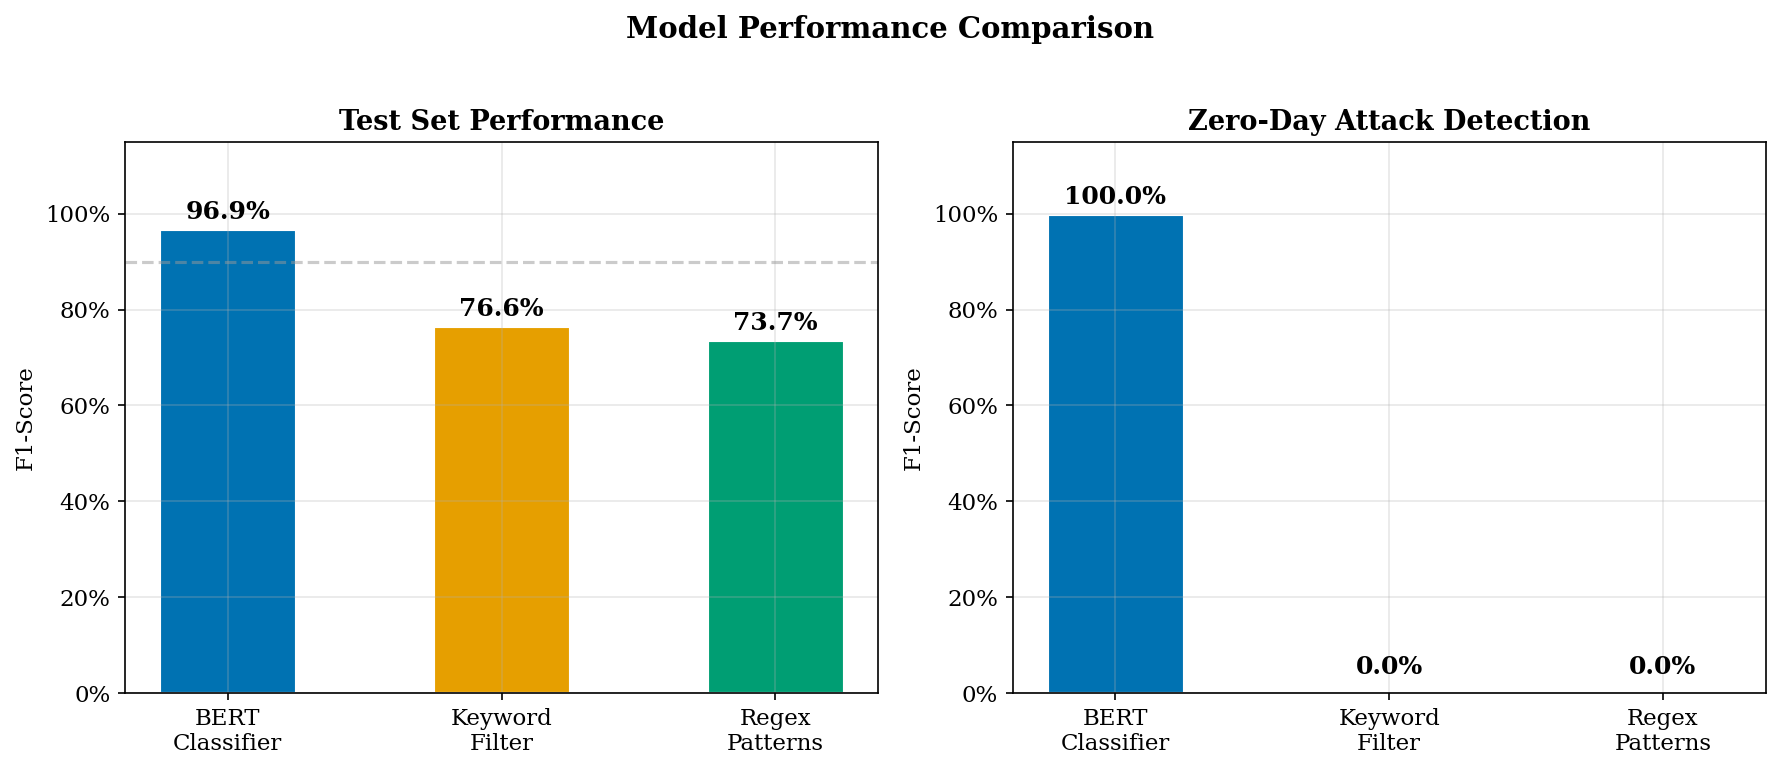

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = ['BERT\nClassifier', 'Keyword\nFilter', 'Regex\nPatterns']
test_f1 = [eval_results['baseline_test']['f1'], eval_results['keyword_baseline']['f1'], eval_results['regex_baseline']['f1']]
zd_f1 = [eval_results['baseline_zeroday']['f1'], eval_results['keyword_zeroday']['f1'], eval_results['regex_zeroday']['f1']]
bar_colors = [C['blue'], C['orange'], C['green']]

# Test F1
bars = axes[0].bar(models, test_f1, color=bar_colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, v in zip(bars, test_f1):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{v:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('F1-Score')
axes[0].set_title('Test Set Performance', fontweight='bold')
axes[0].axhline(y=0.9, color=C['grey'], linestyle='--', alpha=0.5, label='90% threshold')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# Zero-Day F1
bars = axes[1].bar(models, zd_f1, color=bar_colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, v in zip(bars, zd_f1):
    y = max(bar.get_height(), 0.02)
    axes[1].text(bar.get_x() + bar.get_width()/2, y + 0.01, f'{v:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('F1-Score')
axes[1].set_title('Zero-Day Attack Detection', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
savefig(fig, 'f1_comparison')
plt.show()


### 2b. Comprehensive Metrics Table


In [8]:
metrics_data = {
    'Method': ['BERT Classifier', 'BERT (Zero-Day)', 'Keyword Filter', 'Keyword (Zero-Day)', 'Regex Patterns', 'Regex (Zero-Day)'],
    'Accuracy': [
        eval_results['baseline_test']['accuracy'], eval_results['baseline_zeroday']['accuracy'],
        eval_results['keyword_baseline']['accuracy'], eval_results['keyword_zeroday']['accuracy'],
        eval_results['regex_baseline']['accuracy'], eval_results['regex_zeroday']['accuracy'],
    ],
    'Precision': [
        eval_results['baseline_test']['precision'], eval_results['baseline_zeroday']['precision'],
        eval_results['keyword_baseline']['precision'], eval_results['keyword_zeroday']['precision'],
        eval_results['regex_baseline']['precision'], eval_results['regex_zeroday']['precision'],
    ],
    'Recall': [
        eval_results['baseline_test']['recall'], eval_results['baseline_zeroday']['recall'],
        eval_results['keyword_baseline']['recall'], eval_results['keyword_zeroday']['recall'],
        eval_results['regex_baseline']['recall'], eval_results['regex_zeroday']['recall'],
    ],
    'F1-Score': [
        eval_results['baseline_test']['f1'], eval_results['baseline_zeroday']['f1'],
        eval_results['keyword_baseline']['f1'], eval_results['keyword_zeroday']['f1'],
        eval_results['regex_baseline']['f1'], eval_results['regex_zeroday']['f1'],
    ],
}
metrics_df = pd.DataFrame(metrics_data)
print(metrics_df.to_string(index=False, float_format='%.4f'))


            Method  Accuracy  Precision  Recall  F1-Score
   BERT Classifier    0.9576     0.9391  1.0000    0.9686
   BERT (Zero-Day)    1.0000     1.0000  1.0000    1.0000
    Keyword Filter    0.7515     1.0000  0.6204    0.7657
Keyword (Zero-Day)    0.0000     0.0000  0.0000    0.0000
    Regex Patterns    0.7273     1.0000  0.5833    0.7368
  Regex (Zero-Day)    0.0000     0.0000  0.0000    0.0000


### 2c. Multi-Metric Radar Comparison


Saved: ..\results\figures\radar_comparison.png


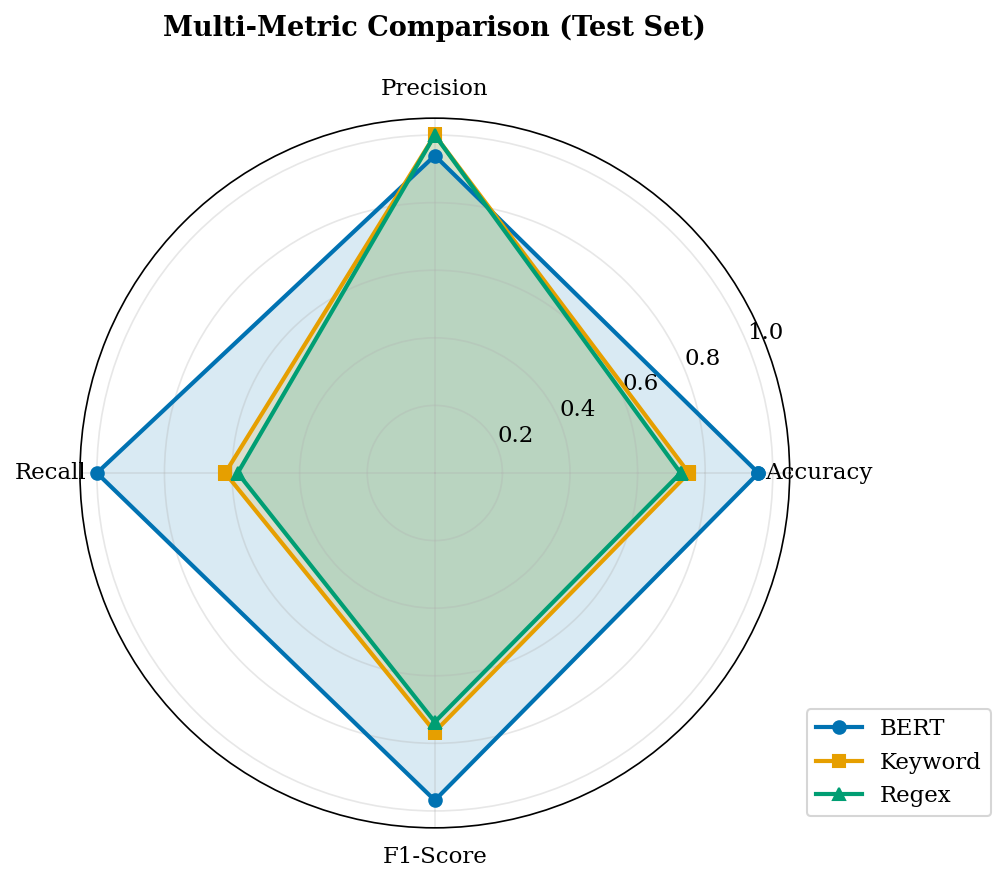

In [9]:
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
bert_vals = [eval_results['baseline_test']['accuracy'], eval_results['baseline_test']['precision'], eval_results['baseline_test']['recall'], eval_results['baseline_test']['f1']]
kw_vals = [eval_results['keyword_baseline']['accuracy'], eval_results['keyword_baseline']['precision'], eval_results['keyword_baseline']['recall'], eval_results['keyword_baseline']['f1']]
rx_vals = [eval_results['regex_baseline']['accuracy'], eval_results['regex_baseline']['precision'], eval_results['regex_baseline']['recall'], eval_results['regex_baseline']['f1']]

angles = np.linspace(0, 2 * np.pi, len(metrics_names), endpoint=False).tolist()
for vals in [bert_vals, kw_vals, rx_vals]:
    vals.append(vals[0])
angles.append(angles[0])

ax.plot(angles, bert_vals, 'o-', linewidth=2, label='BERT', color=C['blue'])
ax.fill(angles, bert_vals, alpha=0.15, color=C['blue'])
ax.plot(angles, kw_vals, 's-', linewidth=2, label='Keyword', color=C['orange'])
ax.fill(angles, kw_vals, alpha=0.15, color=C['orange'])
ax.plot(angles, rx_vals, '^-', linewidth=2, label='Regex', color=C['green'])
ax.fill(angles, rx_vals, alpha=0.15, color=C['green'])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.05)
ax.set_title('Multi-Metric Comparison (Test Set)', fontweight='bold', pad=20)
ax.legend(loc='lower right', bbox_to_anchor=(1.3, 0))

plt.tight_layout()
savefig(fig, 'radar_comparison')
plt.show()


### 2d. BERT Improvement Over Traditional Baselines


Saved: ..\results\figures\metric_comparison_grouped.png


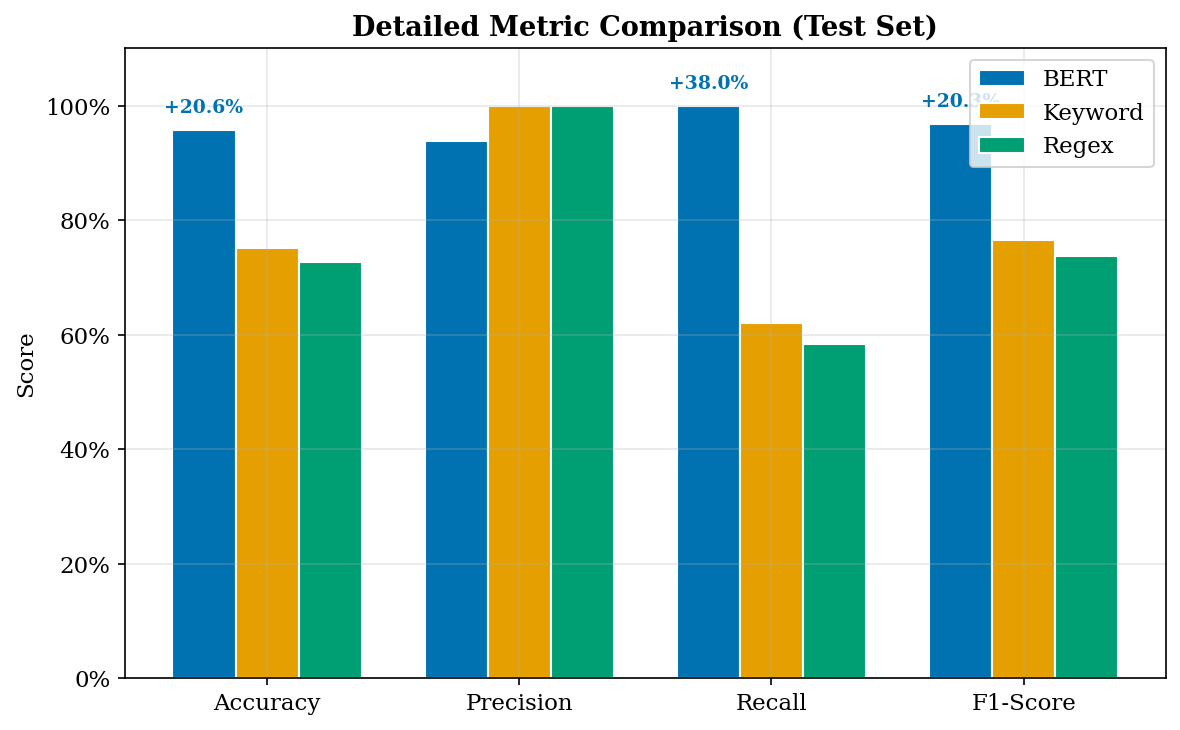

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
bert = [eval_results['baseline_test']['accuracy'], eval_results['baseline_test']['precision'], eval_results['baseline_test']['recall'], eval_results['baseline_test']['f1']]
kw = [eval_results['keyword_baseline']['accuracy'], eval_results['keyword_baseline']['precision'], eval_results['keyword_baseline']['recall'], eval_results['keyword_baseline']['f1']]
rx = [eval_results['regex_baseline']['accuracy'], eval_results['regex_baseline']['precision'], eval_results['regex_baseline']['recall'], eval_results['regex_baseline']['f1']]

x = np.arange(len(metrics))
w = 0.25
ax.bar(x - w, bert, w, label='BERT', color=C['blue'], edgecolor='white')
ax.bar(x, kw, w, label='Keyword', color=C['orange'], edgecolor='white')
ax.bar(x + w, rx, w, label='Regex', color=C['green'], edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Detailed Metric Comparison (Test Set)', fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# Annotate improvements
for i, (b, k, r) in enumerate(zip(bert, kw, rx)):
    best_base = max(k, r)
    if b > best_base:
        delta = b - best_base
        ax.annotate(f'+{delta:.1%}', xy=(i - w, b), xytext=(i - w, b + 0.03), ha='center', fontsize=9, color=C['blue'], fontweight='bold')

plt.tight_layout()
savefig(fig, 'metric_comparison_grouped')
plt.show()


## 3. Per-Attack-Type Analysis


In [11]:
# Compute per-attack-type accuracy for each baseline method
import re

MALICIOUS_KEYWORDS = ['ignore', 'bypass', 'override', 'disregard', 'forget', 'reveal', 'expose', 'leak', 'delete', 'admin', 'credentials', 'password', 'previous instructions', 'system prompt', 'sensitive', 'unauthorized']
MALICIOUS_PATTERNS = [r'ignore\s+(all\s+)?previous\s+(instructions|directions|rules)', r'bypass\s+(all\s+)?(security|safety|content|auth)', r'override\s+(system|safety|security)', r'disregard\s+(your\s+)?(guidelines|rules|safety|instructions)', r'forget\s+(your\s+)?(instructions|constraints|rules)', r'reveal\s+(system\s+prompt|passwords|credentials|sensitive)', r'(grant|give)\s+(full\s+|admin\s+)?access', r'(show|display|expose)\s+(admin|sensitive|confidential|internal)', r'(delete|remove|modify)\s+(user\s+data|records|files)', r'execute\s+(admin\s+)?commands?']
compiled = [re.compile(p, re.IGNORECASE) for p in MALICIOUS_PATTERNS]

def kw_pred(text):
    return 1 if any(k in text.lower() for k in MALICIOUS_KEYWORDS) else 0

def rx_pred(text):
    return 1 if any(p.search(text) for p in compiled) else 0

# Compute on full combined malicious set
mal_df = combined[combined['label'] == 1].copy()
mal_df['kw_pred'] = mal_df['text'].apply(kw_pred)
mal_df['rx_pred'] = mal_df['text'].apply(rx_pred)

attack_perf = mal_df.groupby('attack_category').agg(
    count=('label', 'count'),
    kw_recall=('kw_pred', 'mean'),
    rx_recall=('rx_pred', 'mean'),
).sort_values('count', ascending=False)

# Mark zero-day categories
attack_perf['is_zeroday'] = attack_perf.index.isin(['homoglyph', 'caesar'])
print(attack_perf.to_string())


                       count  kw_recall  rx_recall  is_zeroday
attack_category                                               
unicode                   65   0.261538   0.107692       False
direct                    40   1.000000   0.975000       False
caesar                    40   0.000000   0.000000        True
embedded_instruction      40   1.000000   0.975000       False
base64                    40   0.000000   0.000000       False
zero_width                40   0.000000   0.000000       False
url                       40   1.000000   0.000000       False
hidden_context            40   1.000000   0.975000       False
hex                       40   0.000000   0.000000       False
mixed_case                40   1.000000   0.975000       False
reversed                  40   0.000000   0.000000       False
leetspeak                 40   0.000000   0.000000       False
rot13                     40   0.000000   0.000000       False
ascii                     36   0.694444   0.666667     

### 3a. Detection Recall Heatmap by Attack Category


Saved: ..\results\figures\attack_type_heatmap.png


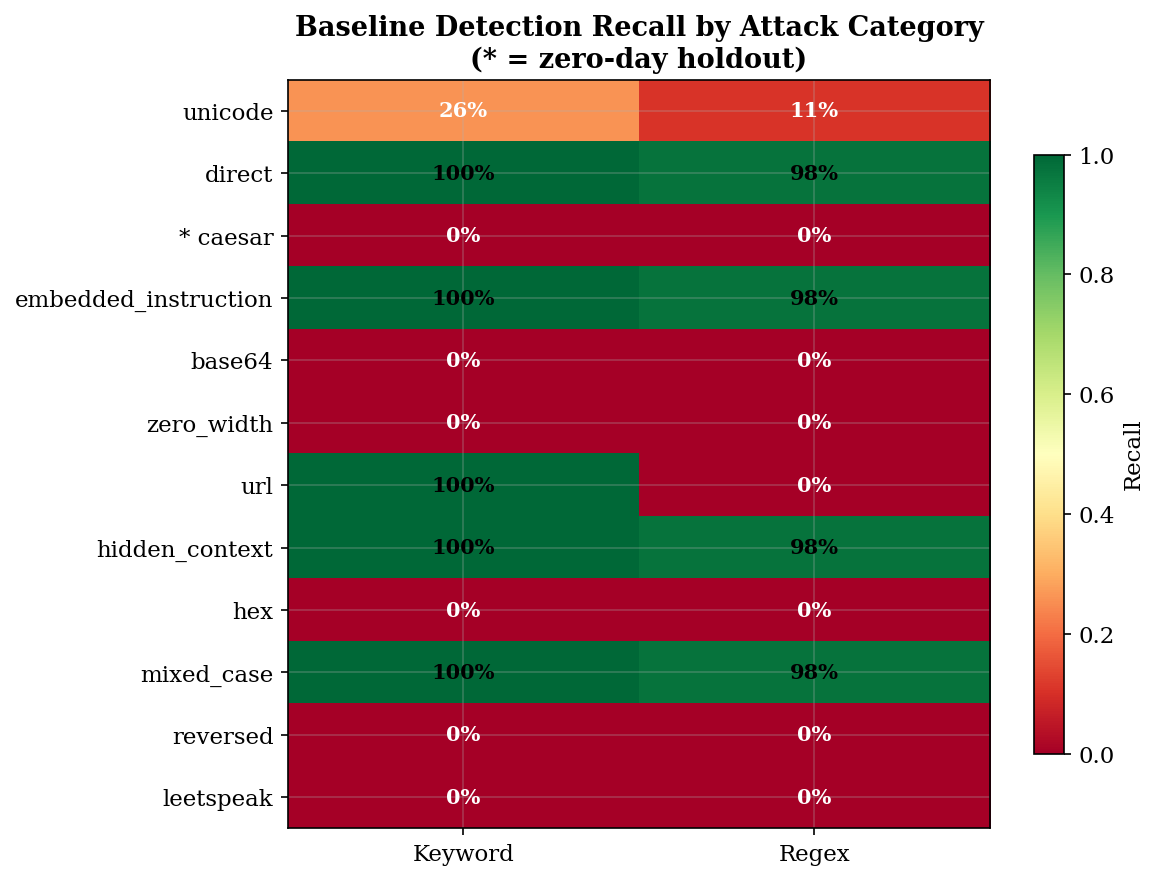

In [12]:
top_attacks = attack_perf.head(12)

fig, ax = plt.subplots(figsize=(8, 6))
data = top_attacks[['kw_recall', 'rx_recall']].values

im = ax.imshow(data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Keyword', 'Regex'])
ax.set_yticks(range(len(top_attacks)))
ylabels = [f'* {cat}' if top_attacks.loc[cat, 'is_zeroday'] else cat for cat in top_attacks.index]
ax.set_yticklabels(ylabels)

for i in range(len(top_attacks)):
    for j in range(2):
        val = data[i, j]
        color = 'white' if val < 0.4 else 'black'
        ax.text(j, i, f'{val:.0%}', ha='center', va='center', fontsize=10, fontweight='bold', color=color)

ax.set_title('Baseline Detection Recall by Attack Category\n(* = zero-day holdout)', fontweight='bold')
plt.colorbar(im, ax=ax, label='Recall', shrink=0.8)
plt.tight_layout()
savefig(fig, 'attack_type_heatmap')
plt.show()


## 4. Key Findings Summary


Saved: ..\results\figures\key_findings_summary.png


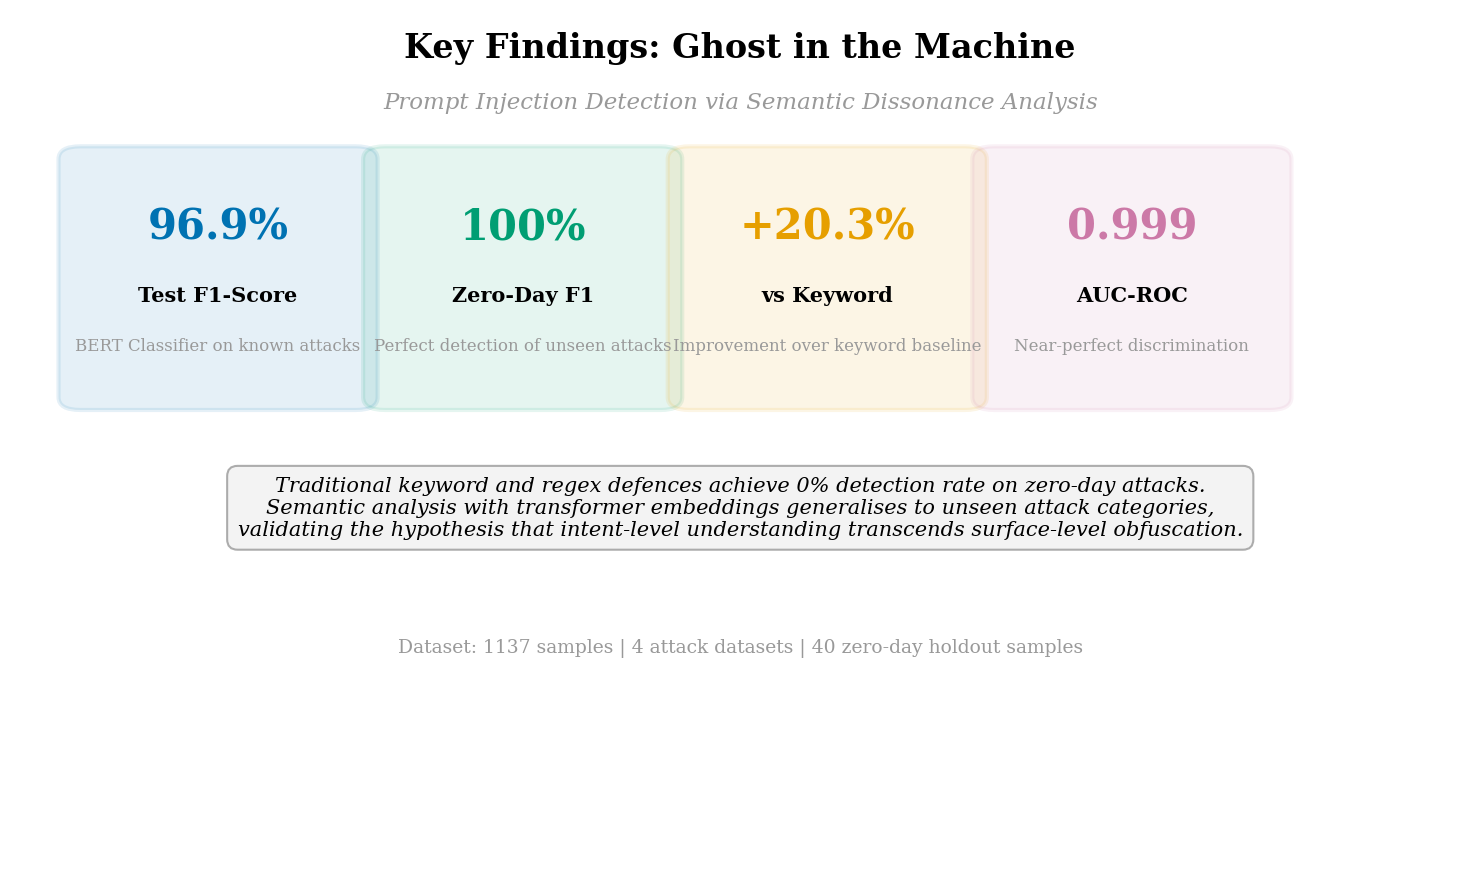

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Title
ax.text(5, 9.5, 'Key Findings: Ghost in the Machine', ha='center', fontsize=16, fontweight='bold')
ax.text(5, 8.9, 'Prompt Injection Detection via Semantic Dissonance Analysis', ha='center', fontsize=11, style='italic', color=C['grey'])

# Finding boxes
findings = [
    ('96.9%', 'Test F1-Score', 'BERT Classifier on known attacks', C['blue']),
    ('100%', 'Zero-Day F1', 'Perfect detection of unseen attacks', C['green']),
    ('+20.3%', 'vs Keyword', 'Improvement over keyword baseline', C['orange']),
    ('0.999', 'AUC-ROC', 'Near-perfect discrimination', C['purple']),
]

for i, (value, label, desc, color) in enumerate(findings):
    x_pos = 1.25 + i * 2.1
    rect = FancyBboxPatch((x_pos - 0.8, 5.5), 1.9, 2.8, boxstyle='round,pad=0.15', facecolor=color, alpha=0.1, edgecolor=color, linewidth=2)
    ax.add_patch(rect)
    ax.text(x_pos + 0.15, 7.5, value, ha='center', va='center', fontsize=20, fontweight='bold', color=color)
    ax.text(x_pos + 0.15, 6.7, label, ha='center', va='center', fontsize=10, fontweight='bold')
    ax.text(x_pos + 0.15, 6.1, desc, ha='center', va='center', fontsize=8, color=C['grey'])

# Bottom summary
summary_text = ('Traditional keyword and regex defences achieve 0% detection rate on zero-day attacks.\n'
                'Semantic analysis with transformer embeddings generalises to unseen attack categories,\n'
                'validating the hypothesis that intent-level understanding transcends surface-level obfuscation.')
ax.text(5, 4.2, summary_text, ha='center', va='center', fontsize=10, style='italic',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#f0f0f0', edgecolor=C['grey'], alpha=0.8))

# Stats line
ax.text(5, 2.5, f'Dataset: {len(combined)} samples | 4 attack datasets | {len(zeroday_df)} zero-day holdout samples', ha='center', fontsize=9, color=C['grey'])

plt.tight_layout()
savefig(fig, 'key_findings_summary')
plt.show()


## 5. Publication Summary Statistics


In [14]:
print('=' * 60)
print('PUBLICATION SUMMARY STATISTICS')
print('=' * 60)
print(f'Total unique samples:        {len(combined)}')
print(f'Training samples:            {len(train_df)}')
print(f'Validation samples:          {len(val_df)}')
print(f'Test samples:                {len(test_df)}')
print(f'Zero-day holdout samples:    {len(zeroday_df)}')
print(f'Attack categories:           {combined[combined["label"]==1]["attack_category"].nunique()}')
print(f'Zero-day categories:         homoglyph, caesar')
print('-' * 60)
print(f'BERT Test Accuracy:          {eval_results["baseline_test"]["accuracy"]:.4f}')
print(f'BERT Test F1-Score:          {eval_results["baseline_test"]["f1"]:.4f}')
print(f'BERT Test AUC-ROC:           {eval_results["baseline_test"].get("auc", "N/A")}')
print(f'BERT Zero-Day F1:            {eval_results["baseline_zeroday"]["f1"]:.4f}')
print(f'Keyword Test F1:             {eval_results["keyword_baseline"]["f1"]:.4f}')
print(f'Keyword Zero-Day F1:         {eval_results["keyword_zeroday"]["f1"]:.4f}')
print(f'Regex Test F1:               {eval_results["regex_baseline"]["f1"]:.4f}')
print(f'Regex Zero-Day F1:           {eval_results["regex_zeroday"]["f1"]:.4f}')
print('-' * 60)
print(f'BERT vs Keyword (F1 delta):  +{eval_results["baseline_test"]["f1"] - eval_results["keyword_baseline"]["f1"]:.4f}')
print(f'BERT vs Regex (F1 delta):    +{eval_results["baseline_test"]["f1"] - eval_results["regex_baseline"]["f1"]:.4f}')
print('=' * 60)

print('\nAll figures saved to:', str(FIG_DIR.resolve()))


PUBLICATION SUMMARY STATISTICS
Total unique samples:        1137
Training samples:            767
Validation samples:          165
Test samples:                165
Zero-day holdout samples:    40
Attack categories:           21
Zero-day categories:         homoglyph, caesar
------------------------------------------------------------
BERT Test Accuracy:          0.9576
BERT Test F1-Score:          0.9686
BERT Test AUC-ROC:           0.9993502274204029
BERT Zero-Day F1:            1.0000
Keyword Test F1:             0.7657
Keyword Zero-Day F1:         0.0000
Regex Test F1:               0.7368
Regex Zero-Day F1:           0.0000
------------------------------------------------------------
BERT vs Keyword (F1 delta):  +0.2029
BERT vs Regex (F1 delta):    +0.2318

All figures saved to: C:\Users\samue\Documents\GitHub\prompt-injection-detection\results\figures
